In [1]:
print("test")

test


In [1]:
import pandas as pd
from LabData.DataLoaders.GutMBLoader import GutMBLoader
from LabData.DataLoaders.SubjectLoader import SubjectLoader
from LabData.DataLoaders.DietLoggingLoader import DietLoggingLoader
from LabData.DataLoaders.LifeStyleLoader import LifeStyleLoader
from LabData.DataLoaders.BodyMeasuresLoader import BodyMeasuresLoader
from LabData.DataAnalyses.TenK_Trajectories.utils import get_diet_logging_around_stage
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize
import seaborn as sns
import re
import pickle
import matplotlib.pyplot as plt

In [2]:
stage = 'baseline' # 'baseline' or '02_00_visit' or '04_00_visit'
calc_adherence = True
david = False
show = False

In [3]:
stage_suf = stage.replace('_00', '') if stage.endswith('_00_visit') else stage

In [4]:
def explore_columns(df):
    for column in df.columns:
        print(column)
        print(df[column].value_counts())

## study_ids = [10, 1001, 1002]
# study_ids = [10]
study_ids=[10, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010]
subjects_dl = SubjectLoader()
subjects_data = subjects_dl.get_data(groupby_reg='first', study_ids=study_ids)
subjects_df = subjects_data.df

print(subjects_df["age"])

RegistrationCode  Date                      
10K_1000028368    2020-03-22 08:26:05.077073    54.0
10K_1000273395    2020-03-05 20:53:54.399388    41.0
10K_1000633050    2021-06-21 14:23:50.372010    66.0
10K_1000942861    2021-06-11 11:30:37.386358    54.0
10K_1001106466    2024-12-15 15:42:22.632981    59.0
                                                ... 
10K_9999226141    2019-12-04 07:07:07.815688    41.0
10K_9999409119    2020-02-22 15:19:08.365584    54.0
10K_9999623844    2023-02-19 01:46:16.838996    55.0
10K_9999732920    2022-12-23 22:20:48.083986    43.0
10K_9999767769    2020-01-31 09:11:04.104338    48.0
Name: age, Length: 31003, dtype: float64


## Load Diet Data

In [6]:
if stage != 'baseline':
    if not david:
        with open('/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/my_lists_diet.pkl', 'rb') as file:
            loaded_lists = pickle.load(file)
        base_features, all_diet_features = loaded_lists
    else:
        with open('/net/mraid20/export/genie/LabData/Analyses/tomerse/david_colab/my_lists_diet.pkl', 'rb') as file:
            loaded_lists = pickle.load(file)
        base_features, all_diet_features = loaded_lists


In [7]:
with open('/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/food_shortnames.pkl', 'rb') as file:
    food_shortnames = pickle.load(file)
food_shortnames

Index(['Acorn squash', 'Alfalfa sprouts', 'Almond Beverage', 'Almond flour',
       'Almond spread', 'Almonds', 'Amba', 'Apple', 'Apple Cake',
       'Apple Vinegar',
       ...
       'Yellow pepper', 'Yogurt', 'Zaatar', 'Zucchini', 'Zucchini Patties',
       'black pepper', 'dried tomato spread', 'emmer wheat bread', 'ginger',
       'kale'],
      dtype='object', name='shortname_eng', length=570)

In [8]:
list(food_shortnames)

['Acorn squash',
 'Alfalfa sprouts',
 'Almond Beverage',
 'Almond flour',
 'Almond spread',
 'Almonds',
 'Amba',
 'Apple',
 'Apple Cake',
 'Apple Vinegar',
 'Apple juice',
 'Apricot',
 'Apropo',
 'Artichoke',
 'Arugula',
 'Asparagus',
 'Avocado',
 'Avocado Sandwich',
 'Bagel',
 'Baguette',
 'Baked apple',
 'Baklava',
 'Balsamic vinegar',
 'Bamba',
 'Banana',
 'Banana Cake',
 'Barbecue sauce',
 'Barley soup',
 'Basil',
 'Bean Noodles',
 'Bean soup',
 'Beans',
 'Beans black-eyed peas',
 'Beef',
 'Beef Cholent',
 'Beef Lasagna',
 'Beef Shawarma',
 'Beer',
 'Beet',
 'Beet Salad',
 'Berries',
 'Biscuit',
 'Bissli',
 'Black beans',
 'Blintzes',
 'Blue Cheese',
 'Blueberries',
 'Boiled corn',
 'Bolognese',
 'Bounty',
 'Brazil nuts',
 'Bread',
 'Bread Crumbs',
 'Brioche',
 'Broccoli',
 'Broth',
 'Brown Rice',
 'Brown Sugar',
 'Brownies',
 'Buckwheat Bread',
 'Buckwheat crackers',
 'Bulgur',
 'Burekas',
 'Butter',
 'Butter Cookies',
 'Caesar Salad',
 'Cake',
 'Calamari',
 'Camembert or Brie',
 

In [13]:
with open('/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/nutr_list_aus.pkl', 'rb') as file:
    nutr_list_aus = pickle.load(file)
nutr_list_aus

Index(['Sugar alcohols', 'SFA 13:0', 'Tocotrienol, delta',
       'Tocotrienol, gamma', 'Tocotrienol, alpha',
       'Fatty acids, total trans-monoenoic',
       'Fatty acids, total trans-polyenoic', 'Tocopherol, delta',
       'Tocopherol, gamma', 'PUFA 18:3i',
       ...
       'MUFA 18:1-11 t (18:1t n-7)', 'Fluoride, F',
       'Vitamin D3 (cholecalciferol)', 'TFA 18:2 t,t', 'Calcium, Ca',
       'Galactose', 'Theobromine', 'Iodine', 'Biotin', 'Energy'],
      dtype='object', length=110)

In [9]:
dll = DietLoggingLoader()
dlld = dll.get_data(study_ids=study_ids)
log = get_diet_logging_around_stage(dlld.df, stage=stage, delta_before=2, delta_after=14)
# log = get_diet_logging_around_stage(dlld.df, stage=stage, delta_before=10, delta_after=0)
log = log.reset_index()
log = log.set_index(['RegistrationCode','Date','food_id'])
print(log.head(10))

                                                    weight unit_id meal_type  \
RegistrationCode Date                      food_id                             
10K_1000942861   2021-12-13 11:14:00+00:00 1006814     6.0       3       NaN   
                 2021-12-13 12:48:00+00:00 1008452   150.0      50       NaN   
                                           1008466   221.0      48       NaN   
                                           1010359   130.0      31       NaN   
                                           1013302   100.0      21       NaN   
                                           1014090   100.0     nan       NaN   
                 2021-12-13 18:11:00+00:00 1006875   182.0      41       NaN   
                 2021-12-13 18:59:00+00:00 1008923   100.0      41       NaN   
                 2021-12-13 20:51:00+00:00 1009132    25.0      38       NaN   
                                           1012898   302.0       1       NaN   

                                       

In [10]:
len(set(log.index.get_level_values(0)))

9997

In [11]:
len(set(log.index.get_level_values(0).values))

9997

## Add Nutrients

In [12]:
# nutr_list = list(dll.food_nutrients.columns)
# nutr_list = ['caffeine_mg','calcium_mg','carbohydrate_g',
# 'cholesterol_mg',
# 'energy_kcal',
# 'iron_mg',
# 'magnesium_mg',
# 'niacin_mg',
# 'phosphorus_mg',
# 'potassium_mg',
# 'protein_g',
# 'raevitamina_ug',
# 'riboflavin_mg',
# 'sodium_mg',
# 'thiamin_mg',
# 'totaldietaryfiber_g',
# 'totalfolate_ug',
# 'totallipid_g',
# 'totalmonounsaturatedfattyacids_g',
# 'totalpolyunsaturatedfattyacids_g',
# 'totalsaturatedfattyacids_g',
# 'vitaminb12_ug',
# 'vitaminb6_mg',
# 'vitaminc_mg',
# 'vitamind_iu',
# 'vitamine_mg',
# 'zinc_mg',
# 'alcohol_g']

# # log_date = dll.add_nutrients(log, nutrient_list=nutr_list)
log_date = dll.add_new_nutrients(log)
log_date


# log_date = pd.read_pickle(f'/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/log_date_add_new_nutrients_{stage}.pkl')
# log_date

weight unit_id meal_type  \
RegistrationCode Date                      food_id                             
10K_1000942861   2021-12-13 11:14:00+00:00 1006814     6.0       3       NaN   
                 2021-12-13 12:48:00+00:00 1008452   150.0      50       NaN   
                                           1008466   221.0      48       NaN   
                                           1010359   130.0      31       NaN   
                                           1013302   100.0      21       NaN   
...                                                    ...     ...       ...   
10K_9999409119   2020-06-22 19:58:00+00:00 1008246    75.0      49       NaN   
                                           1009317    20.0     nan       NaN   
                                           1009978   100.0       1       NaN   
                                           1011036    22.0       2       NaN   
                                           1012976    13.0       2       NaN   

                                                   score    Protein  \
RegistrationCode Date                      food_id                    
10K_1000942861   2021-12-13 11:14:00+00:00 1006814   NaN   0.007200   
                 2021-12-13 12:48:00+00:00 1008452   NaN  32.550001   
                                           1008466   NaN   4.342650   
                                           1010359   NaN   2.730000   
                                           1013302   NaN   9.380000   
...                                                  ...        ...   
10K_9999409119   2020-06-22 19:58:00+00:00 1008246   NaN   0.675000   
                                           1009317   NaN   1.288000   
                                           1009978   NaN   5.500000   
                                           1011036   NaN   0.000000   
                                           1012976   NaN   0.000000   

                                                    Total lipid (fat)  \
RegistrationCode Date                      food_id                      
10K_1000942861   2021-12-13 11:14:00+00:00 1006814            0.00120   
                 2021-12-13 12:48:00+00:00 1008452           19.20000   
                                           1008466           10.17705   
                                           1010359            0.26000   
                                           1013302            1.40400   
...                                                               ...   
10K_9999409119   2020-06-22 19:58:00+00:00 1008246            0.10500   
                                           1009317            7.48300   
                                           1009978            0.85000   
                                           1011036            0.02200   
                                           1012976           13.00000   

                                                    Carbohydrate, by difference  \
RegistrationCode Date                      food_id                                
10K_1000942861   2021-12-13 11:14:00+00:00 1006814                     0.000000   
                 2021-12-13 12:48:00+00:00 1008452                     9.915000   
                                           1008466                    33.415200   
                                           1010359                     7.670000   
                                           1013302                    55.778000   
...                                                                         ...   
10K_9999409119   2020-06-22 19:58:00+00:00 1008246                     2.227500   
                                           1009317                    10.590000   
                                           1009978                    26.440001   
                                           1011036                    16.440601   
                                           1012976                     0.000000   

                                                        E

## Filter Foods Log

In [14]:
log_date = dll.add_short_food_names(log_date)
log_date = dll.add_food_categories(log_date)
log_date

weight unit_id meal_type  \
RegistrationCode Date                      food_id                             
10K_1000942861   2021-12-13 11:14:00+00:00 1006814     6.0       3       NaN   
                 2021-12-13 12:48:00+00:00 1008452   150.0      50       NaN   
                                           1008466   221.0      48       NaN   
                                           1010359   130.0      31       NaN   
                                           1013302   100.0      21       NaN   
...                                                    ...     ...       ...   
10K_9999409119   2020-06-22 19:58:00+00:00 1008246    75.0      49       NaN   
                                           1009317    20.0     nan       NaN   
                                           1009978   100.0       1       NaN   
                                           1011036    22.0       2       NaN   
                                           1012976    13.0       2       NaN   

                                                   score    Protein  \
RegistrationCode Date                      food_id                    
10K_1000942861   2021-12-13 11:14:00+00:00 1006814   NaN   0.007200   
                 2021-12-13 12:48:00+00:00 1008452   NaN  32.550001   
                                           1008466   NaN   4.342650   
                                           1010359   NaN   2.730000   
                                           1013302   NaN   9.380000   
...                                                  ...        ...   
10K_9999409119   2020-06-22 19:58:00+00:00 1008246   NaN   0.675000   
                                           1009317   NaN   1.288000   
                                           1009978   NaN   5.500000   
                                           1011036   NaN   0.000000   
                                           1012976   NaN   0.000000   

                                                    Total lipid (fat)  \
RegistrationCode Date                      food_id                      
10K_1000942861   2021-12-13 11:14:00+00:00 1006814            0.00120   
                 2021-12-13 12:48:00+00:00 1008452           19.20000   
                                           1008466           10.17705   
                                           1010359            0.26000   
                                           1013302            1.40400   
...                                                               ...   
10K_9999409119   2020-06-22 19:58:00+00:00 1008246            0.10500   
                                           1009317            7.48300   
                                           1009978            0.85000   
                                           1011036            0.02200   
                                           1012976           13.00000   

                                                    Carbohydrate, by difference  \
RegistrationCode Date                      food_id                                
10K_1000942861   2021-12-13 11:14:00+00:00 1006814                     0.000000   
                 2021-12-13 12:48:00+00:00 1008452                     9.915000   
                                           1008466                    33.415200   
                                           1010359                     7.670000   
                                           1013302                    55.778000   
...                                                                         ...   
10K_9999409119   2020-06-22 19:58:00+00:00 1008246                     2.227500   
                                           1009317                    10.590000   
                                           1009978                    26.440001   
                                           1011036                    16.440601   
                                           1012976                     0.000000   

                                                        E

In [15]:
log_date = log_date.reset_index()
log_date['Day'] = log_date['Date'].astype(str).str[:10]
log_date['Hour'] = log_date['Date'].astype(str).str[10:16]
log_date.drop('Date', axis=1, inplace=True)
log_date = log_date.set_index(['RegistrationCode','Day','Hour','food_id'])
print(log_date.head())

                                            weight unit_id meal_type score  \
RegistrationCode Day        Hour   food_id                                   
10K_1000942861   2021-12-13  11:14 1006814     6.0       3       NaN   NaN   
                             12:48 1008452   150.0      50       NaN   NaN   
                                   1008466   221.0      48       NaN   NaN   
                                   1010359   130.0      31       NaN   NaN   
                                   1013302   100.0      21       NaN   NaN   

                                              Protein  Total lipid (fat)  \
RegistrationCode Day        Hour   food_id                                 
10K_1000942861   2021-12-13  11:14 1006814   0.007200            0.00120   
                             12:48 1008452  32.550001           19.20000   
                                   1008466   4.342650           10.17705   
                                   1010359   2.730000            0.26000 

In [16]:
# Filter all entries with NaN shortname or Energy
log_date = log_date[~log_date['shortname_eng'].isna()]
log_date = log_date[~log_date['Energy'].isna()]
log_date.shape

(1955840, 165)

In [17]:
len(set(log_date.index.get_level_values(0)))

9995

In [18]:
# Filter foods that are not present in >1% of the cohort
log_date = log_date[log_date['shortname_eng'].isin(food_shortnames)]
log_date.shape

(1909943, 165)

In [19]:
# Filter foods that have no nutrient data, other than sugar substitutes
# Filter rows where all nutrient values are 0
log_date = log_date[~((log_date[nutr_list_aus] == 0).all(axis=1) & (log_date['shortname_eng'] != "Sugar substitute"))]
log_date.shape

(1909583, 165)

In [20]:
# Filter Poppy seed cake and Salep, which have incorrect nutrient data
log_date = log_date[~log_date['shortname_eng'].isin(["Poppy seed cake", "Salep"])]
# Filter taster's choice which has calories inconsistent with other coffee types
log_date = log_date[~log_date['name'].str.contains("Tasters")]
log_date.shape

(1898588, 165)

In [21]:
# Filter Halva entries with incorrect nutrient data
log_date = log_date[~((log_date['shortname_eng'] == "Halva") & (log_date['Total lipid (fat)'] == 0))]
log_date.shape

(1898422, 165)

In [22]:
# Filter unrealistic energy values
log_date = log_date[(log_date["Energy"] >= 0) & (log_date["Energy"] < 3000)]
log_date.shape

(1898062, 165)

In [23]:
# Filter unrealistic weight values
log_date = log_date[(log_date["weight"] >= 0) & (log_date["weight"] < 2400)]
log_date.shape

(1897817, 165)

In [24]:
# Filter duplicate entries
log_date_reset = log_date.reset_index()
log_date = log_date_reset[
    ~log_date_reset.duplicated(subset=['RegistrationCode', 'Day', 'food_id', 'Hour', 'weight'], keep='first')
].set_index(['RegistrationCode', 'Day', 'food_id', 'Hour'])
log_date.shape

(1897815, 165)

In [25]:
# Filter foods without NOVA food scores
NOVA = pd.read_excel('/net/mraid20/export/genie/LabData/Data/10K/foods/processed_foods_mappingV4.xlsx').rename(columns = {'foodid 10k':'food_id'}).dropna(subset=['Score'])
NOVA

,% of calories,food_id,Score,Unnamed: 3,Name 10k,D2ID,Unnamed: 6
0,1.443412,1010363.0,1.0,NaN,סלט ירקות עם שמן זית,75145088,סלט ירקות עם שמן זית
1,1.251932,1012524.0,1.0,NaN,בננה,NaN,NaN
2,1.204728,1013302.0,3.0,NaN,פיתה,NaN,NaN
3,1.043617,1011117.0,1.0,NaN,אבוקדו,63105010,אבוקדו
4,1.002832,1010403.0,1.0,NaN,אורז לבן מבושל,NaN,NaN
...,...,...,...,...,...,...,...
7981,NaN,1014947.0,4.0,NaN,חטיף פיטנס פירות יער,NaN,NaN
7982,NaN,1014948.0,4.0,NaN,יוגורט דנונה פרו 20 קרמל מלוח 0%,NaN,NaN
7983,NaN,1014949.0,4.0,NaN,פילה סויה ענק סוי ג'וי מבושל במים,NaN,NaN
7984,NaN,1014950.0,3.0,NaN,שניצל ללא גלוטן מאמא עוף,NaN,NaN


In [26]:
NOVA['food_id'] = NOVA['food_id'].astype(int).astype(str)
log_date_reset = log_date.reset_index()
merged_df = log_date_reset.merge(NOVA[['food_id', 'Score']], on='food_id', how='left')
log_date = merged_df.set_index(log_date.index.names)
log_date = log_date.dropna(subset=['Score'])
log_date = log_date.rename(columns={'Score': 'NOVA_score'})
log_date.shape

(1893384, 166)

In [27]:
before_any_filters = log_date.reset_index()["RegistrationCode"].nunique()
before_any_filters

9995

In [28]:
# Filter logging days with <500 calories or >4000 calories

total_energy_per_day = log_date.groupby(['RegistrationCode', 'Day'])['Energy'].transform('sum')
log_date['total_energy_per_day'] = total_energy_per_day
log_date = log_date[(log_date['total_energy_per_day'] >= 500) & (log_date['total_energy_per_day'] <= 4000)]
log_date.shape

(1854748, 167)

In [29]:
# Validate filtering
log_date.groupby(['RegistrationCode', 'Day'])['Energy'].transform('sum').describe()

count    1.854748e+06
mean     1.703368e+03
std      6.279708e+02
min      5.000173e+02
25%      1.247481e+03
50%      1.619775e+03
75%      2.072520e+03
max      3.998301e+03
Name: Energy, dtype: float64

In [30]:
# Filter outlier days that might be under-documentation.

# Assuming `log_date` is your DataFrame
# Calculating energy per day
log_date_energy_per_day = log_date.groupby(['RegistrationCode', 'Day'])['Energy'].sum().reset_index()

# Grouping by RegistrationCode to calculate mean and std
stats = log_date_energy_per_day.groupby('RegistrationCode')['Energy'].agg(['mean', 'std'])

# Merging stats back to a new DataFrame
log_date_with_stats = log_date_energy_per_day.merge(stats, on='RegistrationCode')

# Defining outliers: Energy values outside mean ± 2*std
log_date_with_stats['is_outlier_below'] = (log_date_with_stats['Energy'] < (log_date_with_stats['mean'] - 2.5 * log_date_with_stats['std'])) #| \
                                    #(log_date_with_stats['Energy'] > (log_date_with_stats['mean'] + 2 * log_date_with_stats['std']))

# Filtering outlier days
# outliers = log_date_with_stats[log_date_with_stats['is_outlier']][['RegistrationCode', 'Day', 'Energy', 'is_outlier']]
outliers = log_date_with_stats[log_date_with_stats['is_outlier_below']][['RegistrationCode', 'Day', 'Energy', 'is_outlier_below']]

# Display the outliers
print(outliers)
# print(log_date_with_stats[log_date_with_stats['RegistrationCode'] == '10K_1455707672'])


       RegistrationCode         Day       Energy  is_outlier_below
2300     10K_1159499384  2019-09-16   737.000000              True
4116     10K_1293454257  2019-11-22   622.720002              True
4541     10K_1310778947  2022-03-19  1083.861661              True
6550     10K_1455707672  2022-07-28  1086.399995              True
7672     10K_1531044036  2020-09-15   643.520000              True
...                 ...         ...          ...               ...
119920   10K_9521318862  2020-07-26   809.812001              True
121362   10K_9608396847  2020-09-27  1685.716433              True
123445   10K_9748198472  2019-12-30   698.313326              True
123779   10K_9773466425  2022-05-17   699.882500              True
123821   10K_9776138083  2020-07-07   700.706167              True

[77 rows x 4 columns]


In [31]:
# Filter outlier days
log_date = log_date[~log_date_with_stats.set_index(['RegistrationCode', 'Day'])['is_outlier_below']]
log_date.shape

/usr/wisdom/python3/lib/python3.7/site-packages/ipykernel_launcher.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  


(1853994, 167)

In [32]:
log_date.head(20)

weight unit_id meal_type score  \
RegistrationCode Day        food_id Hour                                     
10K_1000942861   2021-12-13 1006814  11:14     6.0       3       NaN   NaN   
                            1008452  12:48   150.0      50       NaN   NaN   
                            1008466  12:48   221.0      48       NaN   NaN   
                            1010359  12:48   130.0      31       NaN   NaN   
                            1013302  12:48   100.0      21       NaN   NaN   
                            1014090  12:48   100.0     nan       NaN   NaN   
                            1006875  18:11   182.0      41       NaN   NaN   
                            1008923  18:59   100.0      41       NaN   NaN   
                            1009132  20:51    25.0      38       NaN   NaN   
                            1012898  20:51   302.0       1       NaN   NaN   
                            1006837  21:56    30.0       2       NaN   NaN   
                            1007849  21:56    35.0      38       NaN   NaN   
                 2021-12-14 1007730  07:35     5.0     nan       NaN   NaN   
                            1013488  07:35   240.0       1       NaN   NaN   
                            1011480  08:06   250.0      16       NaN   NaN   
                            1008191  09:16     5.0      25       NaN   NaN   
                            1010540  13:28   304.0       1       NaN   NaN   
                            1014495  13:28   105.0      31       NaN   NaN   
                            1006875  15:24   182.0      41       NaN   NaN   
                            1006820  18:25   113.0      41       NaN   NaN   

                                              Protein  Total lipid (fat)  \
RegistrationCode Day        food_id Hour                                   
10K_1000942861   2021-12-13 1006814  11:14   0.007200           0.001200   
                            1008452  12:48  32.550001          19.200000   
                            1008466  12:48   4.342650          10.177050   
                            1010359  12:48   2.730000           0.260000   
                            1013302  12:48   9.380000           1.404000   
                            1014090  12:48  17.431999          53.001999   
                            1006875  18:11   1.660750           4.627350   
                            1008923  18:59   0.715000           0.170000   
                            1009132  20:51   6.250000           5.500000   
                            1012898  20:51  15.553000           3.171000   
                            1006837  21:56   2.853000           2.755000   
                            1007849  21:56   3.300500           1.256500   
                 2021-12-14 1007730  07:35   0.309700           1.088000   
                            1013488  07:35   3.825600           1.982400   
                            1011480  08:06   0.000000           0.000000   
                            1008191  09:16   0.006000           0.001000   
                            1010540  13:28   8.451200           8.177600   
                            1014495  13:28  20.264999          15.225000   
                            1006875  15:24   1.660750           4.627350   
                            1006820  18:25   0.409625           0.166675   

                                            Carbohydrate, by difference  \
RegistrationCode Day        food_id Hour                                  
10K_1000942861   2021-12-13 1006814  11:14                     0.000000   
                            1008452  12:48                     9.915000   
                            1008466  12:48                    33.415200   
                            1010359  12:48                     7.670000   
                            1013302  12:48                    55.778000   
                            1014090  12:48                    21.594000   
                            1006875  18:11            

In [33]:
# Filter People with less than 3 days of diet documentation.
# Group by RegistrationCode and count the number of unique days using the index level 'Day'
unique_day_counts = log_date.groupby('RegistrationCode').apply(lambda x: x.index.get_level_values('Day').nunique())

# Filter out RegistrationCodes with less than 3 unique days
valid_registration_codes = unique_day_counts[unique_day_counts >= 3].index

# Create a new DataFrame with only the valid RegistrationCodes
log_date = log_date.loc[valid_registration_codes]

# Display the filtered DataFrame
print(log_date.shape)


(1851470, 167)


In [34]:
people_more_than_3 = log_date.reset_index()["RegistrationCode"].nunique()
people_more_than_3

9762

In [35]:
people_more_than_8 = log_date.reset_index()["RegistrationCode"].nunique()
people_more_than_8

9762

In [36]:
before_any_filters

9995

In [37]:
unique_day_counts

RegistrationCode
10K_1000942861    14
10K_1001201093     5
10K_1002033709     2
10K_1002254441    14
10K_1003113258    14
                  ..
10K_9995823183    15
10K_9996884777    14
10K_9998418497    12
10K_9999226141    15
10K_9999409119    15
Length: 9952, dtype: int64

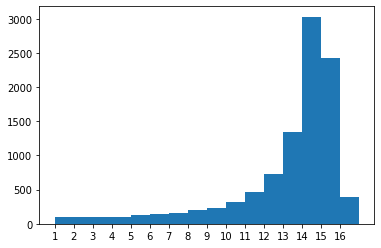

In [38]:
plt.hist(unique_day_counts, bins=range(1, unique_day_counts.max()+2))
plt.xticks(range(1, unique_day_counts.max()+1))
plt.show()


In [39]:
exact_7_days = (unique_day_counts == 7).sum()
more_than_14_days = (unique_day_counts >= 14).sum()
less_than_14_days = ((unique_day_counts < 14) & (unique_day_counts > 7)).sum()

print(f"Number of unique_day_counts with exactly 7 days: {exact_7_days}")
print(f"Number of unique_day_counts with 14 or more days: {more_than_14_days}")
print(f"Number of unique_day_counts with less than 14 days: {less_than_14_days}")


Number of unique_day_counts with exactly 7 days: 162
Number of unique_day_counts with 14 or more days: 5838
Number of unique_day_counts with less than 14 days: 3291


In [40]:
days_saved = ((unique_day_counts < 8) & (unique_day_counts >= 3)).sum()

print(f"Number of unique_day_counts with 4<=x<=7 days: {days_saved}")


Number of unique_day_counts with 4<=x<=7 days: 633


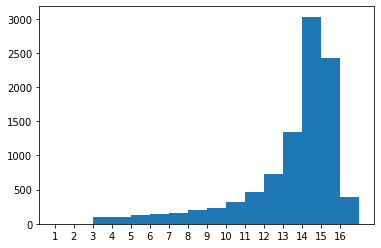

In [41]:
# validate filtering:
# Group by RegistrationCode and count the number of unique days using the index level 'Day'
unique_day_counts_after = log_date.groupby('RegistrationCode').apply(lambda x: x.index.get_level_values('Day').nunique())
plt.hist(unique_day_counts_after, bins=range(1, unique_day_counts_after.max()+2))
plt.xticks(range(1, unique_day_counts_after.max()+1))
plt.show()

In [42]:
# # Validate filtering:
# # Group by RegistrationCode and count the number of unique days using the 'Date' index level
# unique_day_counts_after = log_date.groupby('RegistrationCode').apply(
#     lambda x: pd.to_datetime(x.index.get_level_values('Date')).normalize().nunique()
# )

# # Plot histogram of the unique day counts
# plt.hist(unique_day_counts_after, bins=range(1, unique_day_counts_after.max() + 2))
# plt.xticks(range(1, unique_day_counts_after.max() + 1))
# plt.show()


In [43]:
log_date.groupby(['RegistrationCode', 'Day'])['Energy'].sum().describe()
# max_calories_registration_code = log_date.groupby(['RegistrationCode', 'Day'])['Energy'].sum().idxmax()[0]
# print(max_calories_registration_code)


count    126509.000000
mean       1582.706635
std         621.009151
min         500.017330
25%        1127.023334
50%        1495.781401
75%        1943.315667
max        3998.301062
Name: Energy, dtype: float64

In [44]:
log_date.reset_index()["RegistrationCode"].nunique()

9762

In [45]:
# Log day grouping
log_day = log_date.groupby(['RegistrationCode', 'Day'])[nutr_list_aus].sum()
log_day = log_day[log_day['Energy']>500]
log_day = log_day[log_day['Energy']<4000]
log_day

Sugar alcohols  SFA 13:0  Tocotrienol, delta  \
RegistrationCode Day                                                        
10K_1000942861   2021-12-13            0.00   0.00302              0.0000   
                 2021-12-14            0.00   0.00000              0.0000   
                 2021-12-15           41.00   0.00000              0.0561   
                 2021-12-16            0.00   0.00085              0.0520   
                 2021-12-17            3.77   0.00000              0.1040   
...                                     ...       ...                 ...   
10K_9999409119   2020-06-18            0.00   0.00000              0.0013   
                 2020-06-19            0.00   0.00000              0.0000   
                 2020-06-20            0.00   0.00000              0.0000   
                 2020-06-21            0.00   0.00000              0.0000   
                 2020-06-22            0.00   0.00000              0.0013   

                             Tocotrienol, gamma  Tocotrienol, alpha  \
RegistrationCode Day                                                  
10K_1000942861   2021-12-13             0.14525             0.16000   
                 2021-12-14             0.13650             0.13160   
                 2021-12-15             0.13360             0.16760   
                 2021-12-16             0.43500             0.40275   
                 2021-12-17             0.83900             0.48600   
...                                         ...                 ...   
10K_9999409119   2020-06-18             0.00000             0.19970   
                 2020-06-19             1.38840             0.82760   
                 2020-06-20             1.02300             0.78400   
                 2020-06-21             0.64800             2.48400   
                 2020-06-22             0.33400             0.56290   

                             Fatty acids, total trans-monoenoic  \
RegistrationCode Day                                              
10K_1000942861   2021-12-13                            0.618278   
                 2021-12-14                            0.588173   
                 2021-12-15                            0.138120   
                 2021-12-16                            2.021050   
                 2021-12-17                            1.779190   
...                                                         ...   
10K_9999409119   2020-06-18                            0.657165   
                 2020-06-19                            0.400700   
                 2020-06-20                            0.309170   
                 2020-06-21                            0.114957   
                 2020-06-22                            0.095615   

                             Fatty acids, total trans-polyenoic  \
RegistrationCode Day                                              
10K_1000942861   2021-12-13                            0.277145   
                 2021-12-14                            0.214570   
                 2021-12-15                            0.214890   
                 2021-12-16                            0.372150   
                 2021-12-17                            0.597170   
...                                                         ...   
10K_9999409119   2020-06-18                            0.756475   
                 2020-06-19                            0.591775   
                 2020-06-20                            0.444715   
                 2020-06-21                            0.316830   
                 2020-06-22                            0.203000   

                             Tocopherol, delta  Tocopherol, gamma  PUFA 18:3i  \
RegistrationCode Day                                                            
10K_1000942861   2021-12-13           5.291650          18.818750     0.00435   
                 2021-12-14           1.637000          11.211400     0.00210   
                 2021-12-15        

In [50]:
# log grouped grouping
log_reset = log_day.reset_index().drop("Day", axis=1)

# Group by RegistrationCode and calculate mean for all numeric columns
log_grouped = log_reset.groupby('RegistrationCode').mean()

In [51]:
log_grouped

,Sugar alcohols,SFA 13:0,"Tocotrienol, delta","Tocotrienol, gamma","Tocotrienol, alpha","Fatty acids, total trans-monoenoic","Fatty acids, total trans-polyenoic","Tocopherol, delta","Tocopherol, gamma",PUFA 18:3i,...,MUFA 18:1-11 t (18:1t n-7),"Fluoride, F",Vitamin D3 (cholecalciferol),"TFA 18:2 t,t","Calcium, Ca",Galactose,Theobromine,Iodine,Biotin,Energy
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
10K_1000942861,9.697143,0.000501,0.068279,0.409957,0.457518,1.327476,0.314604,2.149841,13.052668,0.003363,...,6.202028,503.877950,8.661012,1.606542,491.790436,1.057679,132.525238,0.992857,1.291071,1571.283702
10K_1001201093,0.108000,0.000000,0.093060,0.609467,1.110060,0.372779,0.119417,1.176263,6.532370,0.001264,...,4.265477,427.405590,10.002800,1.926324,649.404333,0.341000,280.228806,0.728000,0.000000,1342.752864
10K_1002254441,1.910714,0.001000,0.032857,0.808760,0.276457,0.355381,0.419121,4.973956,29.383490,0.022578,...,5.537042,200.947213,18.209215,3.707023,382.106091,0.194986,5.728571,0.116000,8.911714,1851.100130
10K_1003113258,7.611714,0.003041,0.027543,0.306493,0.585386,0.773858,0.185354,2.777675,17.232621,0.003411,...,5.070008,320.206928,14.933429,1.622940,546.345961,0.387804,77.090573,8.062857,4.569428,1480.383909
10K_1007330152,5.732143,0.001454,0.000000,0.136777,0.690902,4.393966,0.540770,2.805148,11.286454,0.005273,...,4.261163,2170.383250,11.790333,0.920815,426.134654,0.814179,9.171429,20.689286,7.782714,1461.304322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10K_9995823183,2.510400,0.001118,0.022560,0.197907,0.454366,3.130972,0.793244,1.117482,11.011913,0.204843,...,5.411891,493.486799,19.657067,1.625794,1303.385850,0.759873,21.464048,2.341093,7.051467,2466.088451
10K_9996884777,7.240000,0.000036,0.029079,0.763761,0.778768,0.811575,0.284944,0.634404,4.086068,0.005714,...,5.392234,407.612572,6.467964,2.616361,599.699969,0.583932,13.138571,0.487257,0.961714,1170.445819
10K_9998418497,11.629167,0.001254,0.019750,0.297672,0.307538,0.640646,0.381462,1.848378,9.719344,0.189279,...,3.714848,271.209830,17.154417,1.047185,348.060589,0.547471,21.948500,1.403333,3.788917,1211.306192


In [52]:
# Compare scales to aus data, do I need to normalize?
diet_aus = pd.read_csv('/net/mraid20/ifs/wisdom/segal_lab/genie/LabData/Analyses/nastya/diet_predictions/nutr_full_clean_aus.csv', index_col=0)
diet_aus

,Sugar alcohols,SFA 13:0,"Tocotrienol, delta","Tocotrienol, gamma","Tocotrienol, alpha","Fatty acids, total trans-monoenoic","Fatty acids, total trans-polyenoic","Tocopherol, delta","Tocopherol, gamma",PUFA 18:3i,...,MUFA 18:1-11 t (18:1t n-7),"Fluoride, F",Vitamin D3 (cholecalciferol),"TFA 18:2 t,t","Calcium, Ca",Galactose,Theobromine,Iodine,Biotin,Energy
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
3002243,8.363929,0.013355,0.039111,0.381106,1.377526,3.384739,0.548392,5.685655,22.196631,0.070205,...,5.486042,1404.146294,35.161784,4.051402,1044.084451,0.194450,64.233929,5.095714,2.738286,2722.412408
3002905,0.409091,0.002396,0.032473,0.306095,0.589051,2.393944,0.442477,5.479781,20.810984,0.027771,...,5.120025,1132.498702,24.698819,2.075081,1967.868918,0.613236,126.701273,13.974391,9.433636,2446.747244
3014896,0.000000,0.049767,0.062829,0.977160,0.547410,2.293406,0.640618,3.570429,16.690681,0.021976,...,5.213123,536.987756,30.500565,1.590451,774.692329,0.066618,23.011714,4.562714,10.840800,2576.054069
3026711,19.982143,0.000268,0.077810,0.236986,0.377155,1.303912,0.315579,5.148032,15.735059,0.028428,...,3.891844,463.258667,13.430793,1.168945,510.709144,1.162232,60.523095,0.857143,2.862929,1943.021926
3031986,0.000000,0.026846,0.082046,0.794360,0.833545,1.258857,0.298697,3.648543,13.145782,0.080468,...,6.300906,2736.024810,12.902716,0.995391,798.455810,0.576743,9.756333,47.864217,0.455769,1619.096114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3930708,0.000000,0.082878,1.690744,6.396467,3.583500,1.509483,0.427188,3.488478,18.607744,0.006176,...,2.128947,684.384439,12.756778,1.189192,480.563518,0.128322,59.518889,0.606222,0.000000,1877.124296
3944264,7.375385,0.006818,0.088382,0.579965,0.737116,1.739762,0.388671,3.271094,12.662036,0.019885,...,4.697333,496.616045,17.103716,1.561172,782.223461,0.401192,147.052462,1.073037,8.976688,2004.746895
3962829,6.041177,0.020203,0.002552,2.075162,2.427388,1.991559,0.448299,1.018039,13.960442,0.052568,...,3.471668,269.164314,19.312840,0.642868,427.182928,0.383271,28.528431,0.280059,0.742332,1278.707050


In [78]:
# Relative nutrients to energy
nutr_list_no_energy = [nutrient for nutrient in nutr_list_aus if nutrient != "Energy"]
log_grouped[nutr_list_no_energy] = log_grouped[nutr_list_no_energy].div(log_grouped['Energy'], axis=0)

In [5]:
home_path = '/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/'
diet_mb_10k = pd.read_pickle(home_path + f"data/segal_species/diet_mb.pkl")
with open(home_path + f'data/segal_species/my_lists.pkl', 'rb') as file:
    loaded_lists = pickle.load(file)
base_features_10k, all_features_10k, targets_10k = loaded_lists


In [81]:
common_index = log_grouped.index.intersection(diet_mb_10k.index)
filtered = log_grouped.loc[common_index]
filtered

,Sugar alcohols,SFA 13:0,"Tocotrienol, delta","Tocotrienol, gamma","Tocotrienol, alpha","Fatty acids, total trans-monoenoic","Fatty acids, total trans-polyenoic","Tocopherol, delta","Tocopherol, gamma",PUFA 18:3i,...,MUFA 18:1-11 t (18:1t n-7),"Fluoride, F",Vitamin D3 (cholecalciferol),"TFA 18:2 t,t","Calcium, Ca",Galactose,Theobromine,Iodine,Biotin,Energy
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
10K_1000942861,0.006171,3.186658e-07,4.345400e-05,0.000261,0.000291,0.000845,0.000200,0.001368,0.008307,2.140197e-06,...,0.003947,0.320679,0.005512,0.001022,0.312986,0.000673,0.084342,0.000632,0.000822,1571.283702
10K_1001201093,0.000080,0.000000e+00,6.930538e-05,0.000454,0.000827,0.000278,0.000089,0.000876,0.004865,9.413497e-07,...,0.003177,0.318305,0.007449,0.001435,0.483637,0.000254,0.208697,0.000542,0.000000,1342.752864
10K_1002254441,0.001032,5.402193e-07,1.775006e-05,0.000437,0.000149,0.000192,0.000226,0.002687,0.015874,1.219699e-05,...,0.002991,0.108556,0.009837,0.002003,0.206421,0.000105,0.003095,0.000063,0.004814,1851.100130
10K_1003113258,0.005142,2.054004e-06,1.860521e-05,0.000207,0.000395,0.000523,0.000125,0.001876,0.011641,2.304422e-06,...,0.003425,0.216300,0.010088,0.001096,0.369057,0.000262,0.052075,0.005446,0.003087,1480.383909
10K_1007330152,0.003923,9.947083e-07,0.000000e+00,0.000094,0.000473,0.003007,0.000370,0.001920,0.007724,3.608689e-06,...,0.002916,1.485237,0.008068,0.000630,0.291613,0.000557,0.006276,0.014158,0.005326,1461.304322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10K_9995623290,0.000737,1.304784e-06,2.933876e-05,0.000316,0.000622,0.000573,0.000121,0.002407,0.011799,7.476700e-06,...,0.002721,0.519275,0.015114,0.001141,0.368385,0.000564,0.033881,0.000554,0.005144,1654.807728
10K_9995823183,0.001018,4.533495e-07,9.148090e-06,0.000080,0.000184,0.001270,0.000322,0.000453,0.004465,8.306407e-05,...,0.002195,0.200109,0.007971,0.000659,0.528524,0.000308,0.008704,0.000949,0.002859,2466.088451
10K_9996884777,0.006186,3.112367e-08,2.484401e-05,0.000653,0.000665,0.000693,0.000243,0.000542,0.003491,4.882145e-06,...,0.004607,0.348254,0.005526,0.002235,0.512369,0.000499,0.011225,0.000416,0.000822,1170.445819


In [82]:
def explore_columns(df):
    for column in df.columns:
        print(column)
        print(df[column].value_counts())

## study_ids = [10, 1001, 1002]
# study_ids = [10]
study_ids=[10, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010]
subjects_dl = SubjectLoader()
subjects_data = subjects_dl.get_data(groupby_reg='first', study_ids=study_ids)
subjects_df = subjects_data.df

print(subjects_df["age"])

RegistrationCode  Date                      
10K_1000028368    2020-03-22 08:26:05.077073    54.0
10K_1000273395    2020-03-05 20:53:54.399388    41.0
10K_1000633050    2021-06-21 14:23:50.372010    66.0
10K_1000942861    2021-06-11 11:30:37.386358    54.0
10K_1001106466    2024-12-15 15:42:22.632981    59.0
                                                ... 
10K_9999226141    2019-12-04 07:07:07.815688    41.0
10K_9999409119    2020-02-22 15:19:08.365584    54.0
10K_9999623844    2023-02-19 01:46:16.838996    55.0
10K_9999732920    2022-12-23 22:20:48.083986    43.0
10K_9999767769    2020-01-31 09:11:04.104338    48.0
Name: age, Length: 31003, dtype: float64


In [83]:
base_features = ["age", "gender"]
diet_mb = filtered.join(subjects_df[base_features])
diet_mb = diet_mb.reset_index(level=[1], drop=True)
diet_mb = diet_mb.dropna()
diet_mb = diet_mb.rename(columns={"gender": "sex"})
diet_mb

,Sugar alcohols,SFA 13:0,"Tocotrienol, delta","Tocotrienol, gamma","Tocotrienol, alpha","Fatty acids, total trans-monoenoic","Fatty acids, total trans-polyenoic","Tocopherol, delta","Tocopherol, gamma",PUFA 18:3i,...,Vitamin D3 (cholecalciferol),"TFA 18:2 t,t","Calcium, Ca",Galactose,Theobromine,Iodine,Biotin,Energy,age,sex
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
10K_1000942861,0.006171,3.186658e-07,4.345400e-05,0.000261,0.000291,0.000845,0.000200,0.001368,0.008307,2.140197e-06,...,0.005512,0.001022,0.312986,0.000673,0.084342,0.000632,0.000822,1571.283702,54.0,1.0
10K_1001201093,0.000080,0.000000e+00,6.930538e-05,0.000454,0.000827,0.000278,0.000089,0.000876,0.004865,9.413497e-07,...,0.007449,0.001435,0.483637,0.000254,0.208697,0.000542,0.000000,1342.752864,42.0,0.0
10K_1002254441,0.001032,5.402193e-07,1.775006e-05,0.000437,0.000149,0.000192,0.000226,0.002687,0.015874,1.219699e-05,...,0.009837,0.002003,0.206421,0.000105,0.003095,0.000063,0.004814,1851.100130,45.0,1.0
10K_1003113258,0.005142,2.054004e-06,1.860521e-05,0.000207,0.000395,0.000523,0.000125,0.001876,0.011641,2.304422e-06,...,0.010088,0.001096,0.369057,0.000262,0.052075,0.005446,0.003087,1480.383909,49.0,1.0
10K_1007330152,0.003923,9.947083e-07,0.000000e+00,0.000094,0.000473,0.003007,0.000370,0.001920,0.007724,3.608689e-06,...,0.008068,0.000630,0.291613,0.000557,0.006276,0.014158,0.005326,1461.304322,63.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10K_9995623290,0.000737,1.304784e-06,2.933876e-05,0.000316,0.000622,0.000573,0.000121,0.002407,0.011799,7.476700e-06,...,0.015114,0.001141,0.368385,0.000564,0.033881,0.000554,0.005144,1654.807728,54.0,1.0
10K_9995823183,0.001018,4.533495e-07,9.148090e-06,0.000080,0.000184,0.001270,0.000322,0.000453,0.004465,8.306407e-05,...,0.007971,0.000659,0.528524,0.000308,0.008704,0.000949,0.002859,2466.088451,46.0,1.0
10K_9996884777,0.006186,3.112367e-08,2.484401e-05,0.000653,0.000665,0.000693,0.000243,0.000542,0.003491,4.882145e-06,...,0.005526,0.002235,0.512369,0.000499,0.011225,0.000416,0.000822,1170.445819,53.0,0.0


In [84]:
diet_mb = diet_mb.join(diet_mb_10k[targets_10k])
diet_mb

,Sugar alcohols,SFA 13:0,"Tocotrienol, delta","Tocotrienol, gamma","Tocotrienol, alpha","Fatty acids, total trans-monoenoic","Fatty acids, total trans-polyenoic","Tocopherol, delta","Tocopherol, gamma",PUFA 18:3i,...,fBin__86|gBin__428|sBin__630,fBin__86|gBin__429|sBin__631,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
10K_1000942861,0.006171,3.186658e-07,4.345400e-05,0.000261,0.000291,0.000845,0.000200,0.001368,0.008307,2.140197e-06,...,-4.0,-2.963488,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000
10K_1001201093,0.000080,0.000000e+00,6.930538e-05,0.000454,0.000827,0.000278,0.000089,0.000876,0.004865,9.413497e-07,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000
10K_1002254441,0.001032,5.402193e-07,1.775006e-05,0.000437,0.000149,0.000192,0.000226,0.002687,0.015874,1.219699e-05,...,-4.0,-4.000000,-4.000000,-3.228756,-4.0,-4.0,-4.0,-4.000000,-2.383721,-4.000000
10K_1003113258,0.005142,2.054004e-06,1.860521e-05,0.000207,0.000395,0.000523,0.000125,0.001876,0.011641,2.304422e-06,...,-4.0,-3.561030,-4.000000,-3.622636,-4.0,-4.0,-4.0,-4.000000,-3.806766,-4.000000
10K_1007330152,0.003923,9.947083e-07,0.000000e+00,0.000094,0.000473,0.003007,0.000370,0.001920,0.007724,3.608689e-06,...,-4.0,-4.000000,-2.490747,-4.000000,-4.0,-4.0,-4.0,-4.000000,-1.937423,-2.981860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10K_9995623290,0.000737,1.304784e-06,2.933876e-05,0.000316,0.000622,0.000573,0.000121,0.002407,0.011799,7.476700e-06,...,-4.0,-4.000000,-3.054886,-3.358298,-4.0,-4.0,-4.0,-4.000000,-2.648071,-2.558259
10K_9995823183,0.001018,4.533495e-07,9.148090e-06,0.000080,0.000184,0.001270,0.000322,0.000453,0.004465,8.306407e-05,...,-4.0,-4.000000,-3.514511,-3.251132,-4.0,-4.0,-4.0,-2.407299,-2.325184,-4.000000
10K_9996884777,0.006186,3.112367e-08,2.484401e-05,0.000653,0.000665,0.000693,0.000243,0.000542,0.003491,4.882145e-06,...,-4.0,-3.536561,-3.195601,-3.350185,-4.0,-4.0,-4.0,-4.000000,-3.832439,-3.786280


In [8]:
diet_mb = diet_mb.join(diet_mb_10k[["Richness", "Shannon_diversity"]])
diet_mb

,Sugar alcohols,SFA 13:0,"Tocotrienol, delta","Tocotrienol, gamma","Tocotrienol, alpha","Fatty acids, total trans-monoenoic","Fatty acids, total trans-polyenoic","Tocopherol, delta","Tocopherol, gamma",PUFA 18:3i,...,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687,Richness,Shannon_diversity
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
10K_1000942861,0.006171,3.186658e-07,4.345400e-05,0.000261,0.000291,0.000845,0.000200,0.001368,0.008307,2.140197e-06,...,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,189,3.75
10K_1001201093,0.000080,0.000000e+00,6.930538e-05,0.000454,0.000827,0.000278,0.000089,0.000876,0.004865,9.413497e-07,...,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,150,3.34
10K_1002254441,0.001032,5.402193e-07,1.775006e-05,0.000437,0.000149,0.000192,0.000226,0.002687,0.015874,1.219699e-05,...,-4.000000,-3.228756,-4.0,-4.0,-4.0,-4.000000,-2.383721,-4.000000,250,4.25
10K_1003113258,0.005142,2.054004e-06,1.860521e-05,0.000207,0.000395,0.000523,0.000125,0.001876,0.011641,2.304422e-06,...,-4.000000,-3.622636,-4.0,-4.0,-4.0,-4.000000,-3.806766,-4.000000,262,4.29
10K_1007330152,0.003923,9.947083e-07,0.000000e+00,0.000094,0.000473,0.003007,0.000370,0.001920,0.007724,3.608689e-06,...,-2.490747,-4.000000,-4.0,-4.0,-4.0,-4.000000,-1.937423,-2.981860,194,3.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10K_9995623290,0.000737,1.304784e-06,2.933876e-05,0.000316,0.000622,0.000573,0.000121,0.002407,0.011799,7.476700e-06,...,-3.054886,-3.358298,-4.0,-4.0,-4.0,-4.000000,-2.648071,-2.558259,263,4.16
10K_9995823183,0.001018,4.533495e-07,9.148090e-06,0.000080,0.000184,0.001270,0.000322,0.000453,0.004465,8.306407e-05,...,-3.514511,-3.251132,-4.0,-4.0,-4.0,-2.407299,-2.325184,-4.000000,206,4.23
10K_9996884777,0.006186,3.112367e-08,2.484401e-05,0.000653,0.000665,0.000693,0.000243,0.000542,0.003491,4.882145e-06,...,-3.195601,-3.350185,-4.0,-4.0,-4.0,-4.000000,-3.832439,-3.786280,257,4.01


In [9]:
diet_mb.to_pickle(home_path + f"data/segal_species/diet_mb_new_nutrients.pkl")